# 약물 수요 예측 프로젝트 - Step 3: 모델링
**목표**: 서울시 25개 구의 월별 약물 처방 수량 예측  
**모델**: Linear Regression (기준) → XGBoost → LightGBM  
**Train**: 2023-10 ~ 2025-04 (19개월) / **Test**: 2025-05 ~ 2025-10 (6개월)

## 0. 환경 설정

In [14]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import lightgbm as lgb
import warnings, os
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

RANDOM_STATE = 42
OUT_DATA = 'output/data'
OUT_FIG  = 'output/figures'
os.makedirs(OUT_FIG, exist_ok=True)

print('환경 설정 완료')
print(f'  XGBoost  버전: {xgb.__version__}')
print(f'  LightGBM 버전: {lgb.__version__}')

환경 설정 완료
  XGBoost  버전: 3.2.0
  LightGBM 버전: 4.6.0


## 1. 마스터 데이터 로드

In [15]:
df = pd.read_csv(f'{OUT_DATA}/merged_master.csv', encoding='utf-8-sig')
df['기간_dt'] = pd.to_datetime(df['기간_dt'])
df = df.sort_values(['약물구분','시군구명칭','기간_dt']).reset_index(drop=True)

print(f'shape : {df.shape}')
print(f'기간  : {df["기간_dt"].min().strftime("%Y-%m")} ~ {df["기간_dt"].max().strftime("%Y-%m")}')
print(f'구 수 : {df["시군구명칭"].nunique()}')
print(f'약물  : {df["약물구분"].unique().tolist()}')
display(df[['약물구분','시군구명칭','기간_dt','수량','처방량_per_capita','고령인구비율']].head(5))

shape : (1250, 31)
기간  : 2023-10 ~ 2025-10
구 수 : 25
약물  : ['A10A', 'A10B']


,약물구분,시군구명칭,기간_dt,수량,처방량_per_capita,고령인구비율
0,A10A,강남구,2023-10-01,34428,0.062672,0.227009
1,A10A,강남구,2023-11-01,41946,0.076358,0.227009
2,A10A,강남구,2023-12-01,35364,0.064376,0.227009
3,A10A,강남구,2024-01-01,39015,0.071022,0.227009
4,A10A,강남구,2024-02-01,37368,0.068024,0.227009


## 2. Feature Engineering

In [16]:
# ── Feature Engineering: 시계열 예측용 변수 생성 ─────────────────

def make_features(df):
    """
    시계열 예측을 위한 Feature 생성

    생성 Feature:
      [Lag]     lag_1, lag_2, lag_3       : 1~3개월 전 처방 수량
      [Rolling] rolling_mean_3            : 직전 3개월 이동 평균
                rolling_std_3             : 직전 3개월 이동 표준편차
      [변화율]  lag1_pct_change           : 전월 대비 증감률
      [시간]    month_sin, month_cos      : 월 계절성 (삼각함수 인코딩)
      [인코딩]  gu_encoded                : 구명칭 → 정수 레이블
                drug_encoded              : 약물구분 → 0(A10A)/1(A10B)
    """
    df = df.copy()
    group = ['약물구분', '시군구명칭']   # 그룹 기준: 약물 × 구

    # ── Lag features: 이전 N개월 값 ──────────────────────────────
    for lag in [1, 2, 3]:
        df[f'lag_{lag}'] = df.groupby(group)['수량'].shift(lag)

    # ── Rolling features: 직전 3개월 통계 (데이터 누수 방지) ─────
    shifted = df.groupby(group)['수량'].shift(1)
    df['rolling_mean_3'] = shifted.groupby(
        [df['약물구분'], df['시군구명칭']]
    ).transform(lambda x: x.rolling(3).mean())
    df['rolling_std_3'] = shifted.groupby(
        [df['약물구분'], df['시군구명칭']]
    ).transform(lambda x: x.rolling(3).std())

    # ── 전월 대비 증감률 (분모 0 방지: +1) ───────────────────────
    df['lag1_pct_change'] = (df['lag_1'] - df['lag_2']) / (df['lag_2'] + 1)

    # ── 월 계절성 인코딩 (삼각함수) ─────────────────────────────
    df['month_sin'] = np.sin(2 * np.pi * df['월'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['월'] / 12)

    # ── 범주형 변수 인코딩 ───────────────────────────────────────
    le = LabelEncoder()
    df['gu_encoded']   = le.fit_transform(df['시군구명칭'])
    df['drug_encoded'] = (df['약물구분'] == 'A10B').astype(int)  # A10A=0, A10B=1

    return df, le

df_feat, le_gu = make_features(df)

# lag 생성으로 인한 앞부분 결측 행 제거 (각 구별 최초 3개월)
df_feat = df_feat.dropna(
    subset=['lag_1', 'lag_2', 'lag_3', 'rolling_mean_3']
).reset_index(drop=True)

print(f'Feature 생성 후 shape: {df_feat.shape}')
new_feat = ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'rolling_std_3',
            'lag1_pct_change', 'month_sin', 'month_cos', 'gu_encoded', 'drug_encoded']
print(f'생성된 feature: {new_feat}')
display(df_feat[['약물구분', '시군구명칭', '기간_dt', '수량'] + new_feat[:5]].head(5))

Feature 생성 후 shape: (1100, 41)
생성된 feature: ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'rolling_std_3', 'lag1_pct_change', 'month_sin', 'month_cos', 'gu_encoded', 'drug_encoded']


,약물구분,시군구명칭,기간_dt,수량,lag_1,lag_2,lag_3,rolling_mean_3,rolling_std_3
0,A10A,강남구,2024-01-01,39015,35364.0,41946.0,34428.0,37246.0,4097.136073
1,A10A,강남구,2024-02-01,37368,39015.0,35364.0,41946.0,38775.0,3297.556823
2,A10A,강남구,2024-03-01,37788,37368.0,39015.0,35364.0,37249.0,1828.406683
3,A10A,강남구,2024-04-01,38622,37788.0,37368.0,39015.0,38057.0,855.817153
4,A10A,강남구,2024-05-01,36742,38622.0,37788.0,37368.0,37926.0,638.288336


## 3. 학습/테스트 분리 (시간 기준)

In [17]:
TRAIN_END = '2025-04'
TEST_START = '2025-05'

FEATURE_COLS = [
    'lag_1','lag_2','lag_3',
    'rolling_mean_3','rolling_std_3','lag1_pct_change',
    'month_sin','month_cos',
    '연도','월',
    '총거주자수','세대당인구','남여비율','고령인구비율',
    'gu_encoded','drug_encoded'
]
TARGET = '수량'

train = df_feat[df_feat['기간_dt'] <= TRAIN_END]
test  = df_feat[df_feat['기간_dt'] >= TEST_START]

X_train, y_train = train[FEATURE_COLS], train[TARGET]
X_test,  y_test  = test[FEATURE_COLS],  test[TARGET]

print(f'Train: {train["기간_dt"].min().strftime("%Y-%m")} ~ {train["기간_dt"].max().strftime("%Y-%m")}  ({len(train):,}행)')
print(f'Test : {test["기간_dt"].min().strftime("%Y-%m")} ~ {test["기간_dt"].max().strftime("%Y-%m")}  ({len(test):,}행)')
print(f'Feature 수: {len(FEATURE_COLS)}')

Train: 2024-01 ~ 2025-04  (800행)
Test : 2025-05 ~ 2025-10  (300행)
Feature 수: 16


## 4. 공통 평가 함수

In [18]:
def evaluate(y_true, y_pred, model_name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # MAPE: 실제값 0 제외
    mask = y_true > 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    print(f'[{model_name:20s}]  MAE={mae:>12,.1f}  RMSE={rmse:>12,.1f}  MAPE={mape:>6.2f}%')
    return {'모델': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

results = []
print('평가 함수 준비 완료')

평가 함수 준비 완료


## 5. Linear Regression (기준 모델)

In [19]:
lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)
pred_lr = np.clip(pred_lr, 0, None)  # 음수 방지

res = evaluate(y_test.values, pred_lr, 'Linear Regression')
results.append({**res, 'pred': pred_lr})

# 계수 상위 feature
coef_df = pd.DataFrame({'feature': FEATURE_COLS, 'coef': lr.coef_})
coef_df = coef_df.reindex(coef_df['coef'].abs().sort_values(ascending=False).index)
print()
print('상위 5 계수:')
display(coef_df.head(5))

[Linear Regression   ]  MAE=   107,020.9  RMSE=   159,185.6  MAPE=194.39%

상위 5 계수:


,feature,coef
8,연도,66228.093799
15,drug_encoded,56619.238141
12,남여비율,-54541.943291
7,month_cos,32610.668686
13,고령인구비율,-28307.018212


## 6. XGBoost

In [20]:
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    verbosity=0,
)
xgb_model.fit(X_train, y_train, verbose=False)

pred_xgb = xgb_model.predict(X_test)
pred_xgb = np.clip(pred_xgb, 0, None)  # 음수 방지

res = evaluate(y_test.values, pred_xgb, 'XGBoost')
results.append({**res, 'pred': pred_xgb})

# Feature Importance
fi_xgb = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)
print()
print('XGBoost Feature Importance (상위 8):')
display(fi_xgb.head(8))

[XGBoost             ]  MAE=    96,656.9  RMSE=   175,124.8  MAPE= 23.43%

XGBoost Feature Importance (상위 8):


,feature,importance
3,rolling_mean_3,0.260123
1,lag_2,0.251469
2,lag_3,0.241321
0,lag_1,0.206810
8,연도,0.007877
10,총거주자수,0.007714
7,month_cos,0.004449
14,gu_encoded,0.003527


## 7. LightGBM

In [21]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    verbosity=-1
)
lgb_model.fit(X_train, y_train)

pred_lgb = lgb_model.predict(X_test)
pred_lgb = np.clip(pred_lgb, 0, None)

res = evaluate(y_test.values, pred_lgb, 'LightGBM')
results.append({**res, 'pred': pred_lgb})

fi_lgb = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False)
print()
print('LightGBM Feature Importance (상위 8):')
display(fi_lgb.head(8))

[LightGBM            ]  MAE=   100,252.9  RMSE=   176,078.9  MAPE= 37.47%

LightGBM Feature Importance (상위 8):


,feature,importance
0,lag_1,554
4,rolling_std_3,398
2,lag_3,347
1,lag_2,336
5,lag1_pct_change,286
3,rolling_mean_3,225
7,month_cos,223
14,gu_encoded,147


## 8. 모델 성능 비교

=== 모델 성능 비교 ===


,MAE,RMSE,MAPE
모델,,,
Linear Regression,"107,020.9","159,185.6",194.39%
XGBoost,"96,656.9","175,124.8",23.43%
LightGBM,"100,252.9","176,078.9",37.47%


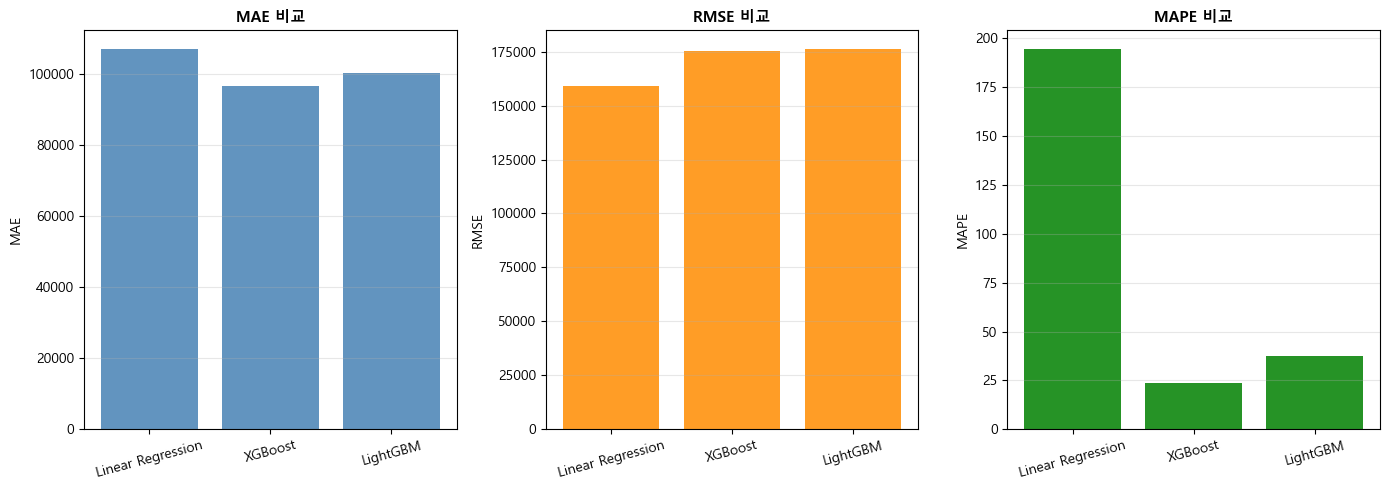

저장: output/figures/09_model_comparison.png


In [22]:
# ── 모델 성능 비교 테이블 ────────────────────────────────────────
df_results = pd.DataFrame(
    [{k: v for k, v in r.items() if k != 'pred'} for r in results]
).set_index('모델')

print('=== 모델 성능 비교 ===')
display(df_results.style.format({'MAE': '{:,.1f}', 'RMSE': '{:,.1f}', 'MAPE': '{:.2f}%'})
        .highlight_min(color='none', axis=0))

# ── 성능 지표 Bar Chart ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ['MAE', 'RMSE', 'MAPE']
colors  = ['steelblue', 'darkorange', 'green']

for ax, metric, color in zip(axes, metrics, colors):
    ax.bar(df_results.index, df_results[metric], color=color, alpha=0.85)
    ax.set_title(f'{metric} 비교', fontsize=11, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
path = f'{OUT_FIG}/09_model_comparison.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {path}')

## 9. Feature Importance 시각화 (XGBoost vs LightGBM)

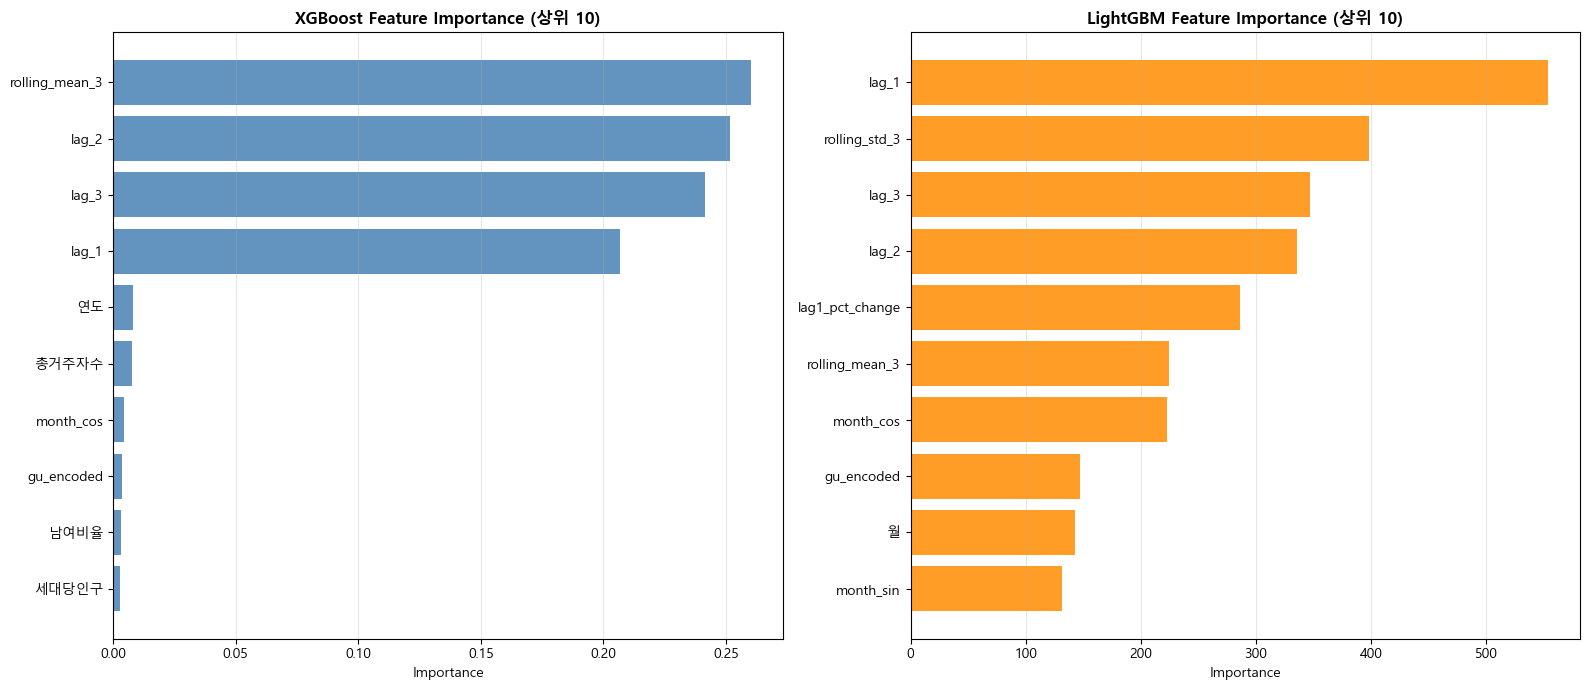

저장: output/figures/10_feature_importance.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, fi_df, name, color in zip(
    axes,
    [fi_xgb.head(10), fi_lgb.head(10)],
    ['XGBoost', 'LightGBM'],
    ['steelblue', 'darkorange']
):
    ax.barh(fi_df['feature'][::-1], fi_df['importance'][::-1], color=color, alpha=0.85)
    ax.set_title(f'{name} Feature Importance (상위 10)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance')
    ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
path = f'{OUT_FIG}/10_feature_importance.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {path}')

## 10. 예측 vs 실제 비교 (구별 샘플)

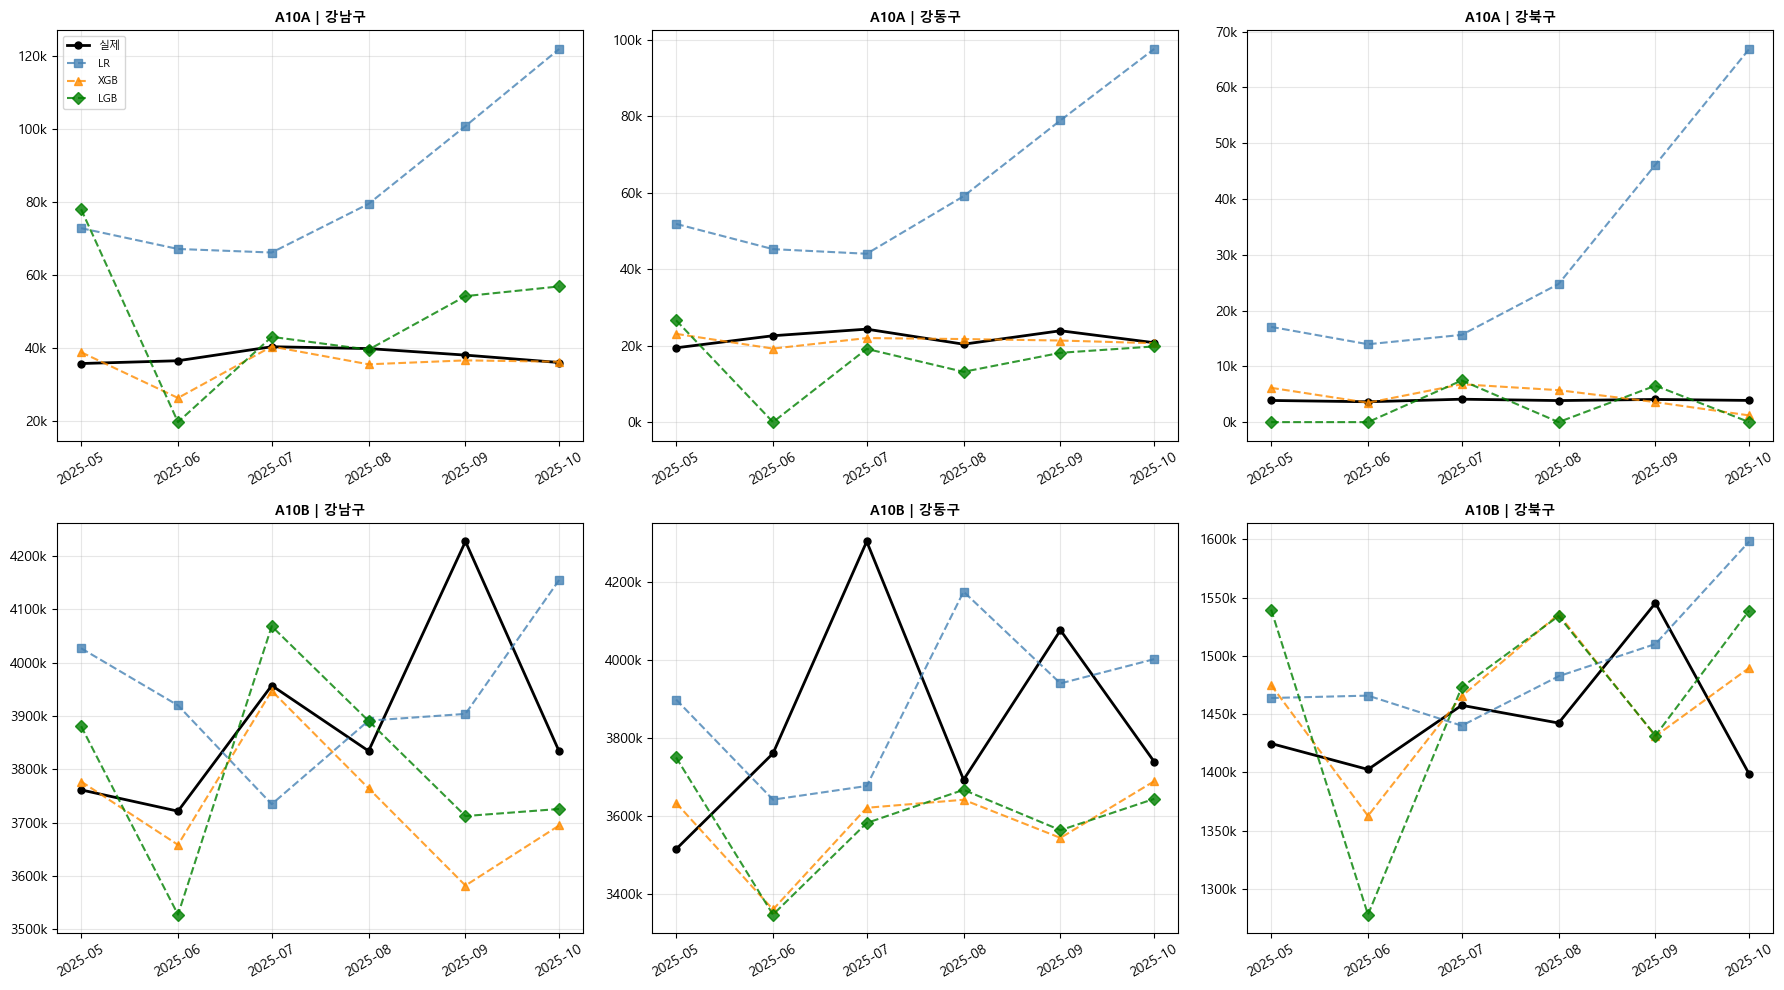

저장: output/figures/11_pred_vs_actual.png


In [24]:
# ── 테스트 데이터에 예측값 병합 ─────────────────────────────────
test_plot = test.copy().reset_index(drop=True)
test_plot['pred_lr']  = pred_lr
test_plot['pred_xgb'] = pred_xgb
test_plot['pred_lgb'] = pred_lgb

# ── 구별 샘플 시각화 (약물 × 구 조합, 각 3개 구) ─────────────────
sample_gu_list = test_plot['시군구명칭'].unique()[:3]
drug_list = ['A10A', 'A10B']

fig, axes = plt.subplots(len(drug_list), len(sample_gu_list),
                         figsize=(18, 10), sharey=False)

for row_idx, drug in enumerate(drug_list):
    for col_idx, gu in enumerate(sample_gu_list):
        ax = axes[row_idx, col_idx]
        sub = test_plot[(test_plot['약물구분'] == drug) & (test_plot['시군구명칭'] == gu)]

        ax.plot(sub['기간_dt'], sub['수량'],    'ko-', label='실제', linewidth=2, markersize=5)
        ax.plot(sub['기간_dt'], sub['pred_lr'],  's--', color='steelblue',  label='LR',  alpha=0.8)
        ax.plot(sub['기간_dt'], sub['pred_xgb'], '^--', color='darkorange', label='XGB', alpha=0.8)
        ax.plot(sub['기간_dt'], sub['pred_lgb'], 'D--', color='green',      label='LGB', alpha=0.8)

        ax.set_title(f'{drug} | {gu}', fontsize=10, fontweight='bold')
        ax.tick_params(axis='x', rotation=30)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
        ax.grid(True, alpha=0.3)
        if row_idx == 0 and col_idx == 0:
            ax.legend(fontsize=8)

plt.tight_layout()
path = f'{OUT_FIG}/11_pred_vs_actual.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {path}')

## 11. 잔차 분석

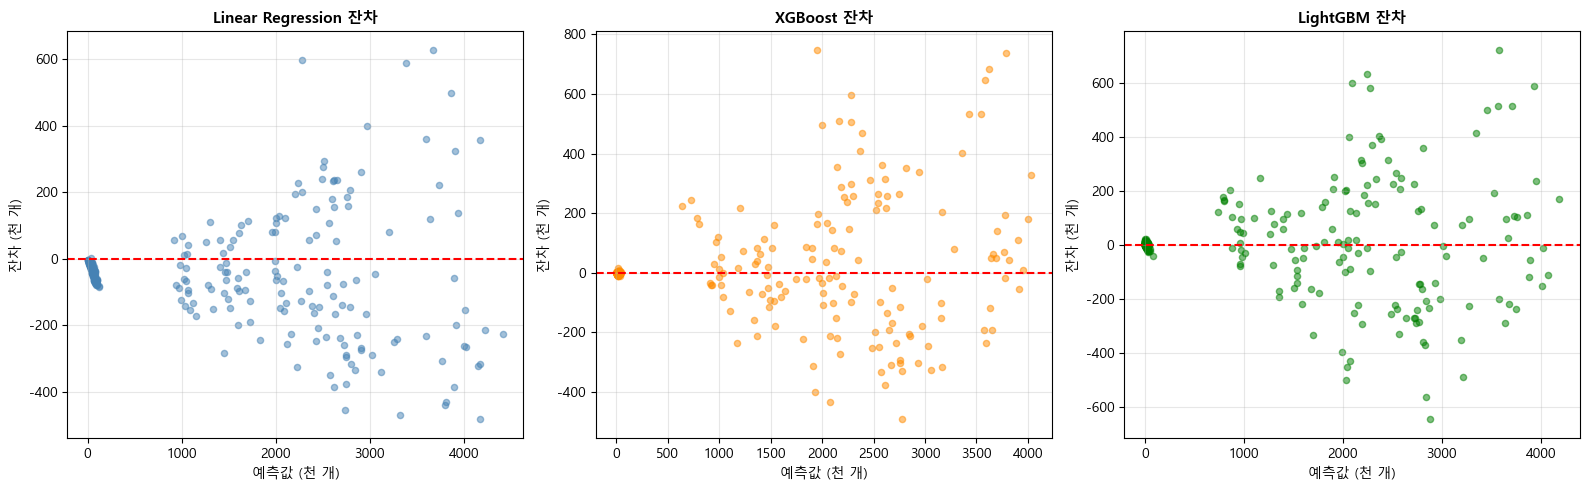

저장: output/figures/12_residual_plot.png


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
model_preds = [('Linear Regression', pred_lr, 'steelblue'),
               ('XGBoost',           pred_xgb, 'darkorange'),
               ('LightGBM',          pred_lgb, 'green')]

for ax, (name, pred, color) in zip(axes, model_preds):
    residuals = y_test.values - pred
    ax.scatter(pred/1e3, residuals/1e3, alpha=0.5, color=color, s=20)
    ax.axhline(0, color='red', linewidth=1.5, linestyle='--')
    ax.set_title(f'{name} 잔차', fontsize=11, fontweight='bold')
    ax.set_xlabel('예측값 (천 개)')
    ax.set_ylabel('잔차 (천 개)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
path = f'{OUT_FIG}/12_residual_plot.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {path}')

## 12. 예측 결과 저장

In [26]:
test_out = test.copy().reset_index(drop=True)
test_out['pred_lr']  = pred_lr
test_out['pred_xgb'] = pred_xgb
test_out['pred_lgb'] = pred_lgb

test_out.to_csv(f'{OUT_DATA}/test_predictions.csv', index=False, encoding='utf-8-sig')

# 성능 요약 저장
df_results.to_csv(f'{OUT_DATA}/model_performance.csv', encoding='utf-8-sig')

print(f'저장: {OUT_DATA}/test_predictions.csv')
print(f'저장: {OUT_DATA}/model_performance.csv')
print()
print('=' * 55)
print(f'최우수 모델: {df_results["MAPE"].idxmin()} (MAPE {df_results["MAPE"].min():.2f}%)')
print('=' * 55)

저장: output/data/test_predictions.csv
저장: output/data/model_performance.csv

최우수 모델: XGBoost (MAPE 23.43%)
